# [LAB 11] 4. 시계열의 통계적 접근
![alt text](image-20.png)
## #01. 준비작업
### 1. 라이브러리 참조

In [1]:
# 라이브러리 기본 참조
from hossam import load_data
from helpers import *

from pandas import DataFrame, Series
import numpy as np

# 자기상관, 부분자기상관 계수 계산
from statsmodels.tsa.stattools import acf, pacf

# 자기상관 그래프
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

📦 아이티윌 이광호 강사가 제작한 라이브러리를 사용중입니다.
📚 자세한 사용 방법은 https://py.hossam.kr 을 참고하세요.
📧 Email: leekh4232@gmail.com
🎬 Youtube: https://www.youtube.com/@hossam-codingclub
📝 Blog: https://blog.hossam.kr/
🔖 Version: 0.5.31


### 2. 데이터 불러오기 + 인덱스 설정

In [2]:
origin = load_data('air_passengers')

# 1단원에서 만든 함수로 인덱스를 잡는다
df = my_ts.set_index(origin, 'Month', freq='MS')

print(f'데이터셋 크기: {df.shape[0]}행 | 인덱스 가격: {df.index.freqstr}')

📚 어느 항공사의 월간 탑승객 수 (출처: https://www.kaggle.com/datasets/rakannimer/air-passengers)
데이터셋 크기: 144행 | 인덱스 가격: MS


### 3. 정상 시계열 만들기
- 앞 단원들을 거치면서 얻은 결론(로그변환 + 1차 차분 + 계절차분(12))을 적용

In [3]:
# 정상 시계열로 변환
stationary = my_ts.transform(df, 'Passengers', log=True, diff=1, seasonal_diff=1, period=12)

# 변환 결과에 대한 정상성 검정
my_ts.adf_test(stationary)

,관측치 수,검정통계량(ADF),p-value,사용 시차,1% 기각값,5% 기각값,10% 기각값,표준편차,정상성,판정
Passengers,131,-4.443,0.000,12,-3.487,-2.886,-2.580,0.046,True,정상


- p-value = 0.0002로 정상성을 충족한다
- 관측치는 144개 -> 131개로 줄었다(1차 차분에서 1개, 계절차분에서 12개 소실)
- 이 단원에서 다루는 ACF/PACF는 반드시 정상 시계열에 적용해야 한다.

## #02. 자기상관(Autocorrelation)의 이해
![alt text](image-21.png)

### 1. 현재 데이터와 비교하기 위한 직전 데이터 준비
- pandas의 shift 함수는 데이터를 한 칸씩 이동시킨다.
    - 원본 : 1,2,3,4,5 -> shift: NaN,1,2,3,4
- 원본과 shift 결과를 비교하면 자신과 자신의 직전값을 비교할 수 있다.

In [4]:
# 원본 데이터를 한 칸씩 아래로 이동시킨다. '1,2,3' --> 'NaN,1,2'
# 음수를 부여하면 한 칸씩 위로 당긴다. '1,2,3' --> '2,3,NaN'
origin_shift = df['Passengers'].shift(1)
or_shift = DataFrame({'원본' : df['Passengers'],
                      '원본 shift' : origin_shift})
display(or_shift.head(10))

# 정상 시계열을 한 칸씩 아래로 이동시킨다.
stationary_shift = stationary.shift(1)
st_shift = DataFrame({'정상 시계열' : stationary,
                      '정상 시계열 shift' : stationary_shift})
display(st_shift.head(10))

,원본,원본 shift
Month,,
1949-01-01,112,NaN
1949-02-01,118,112.000
1949-03-01,132,118.000
1949-04-01,129,132.000
1949-05-01,121,129.000
1949-06-01,135,121.000
1949-07-01,148,135.000
1949-08-01,148,148.000
1949-09-01,136,148.000


,정상 시계열,정상 시계열 shift
Month,,
1950-02-01,0.039,NaN
1950-03-01,0.000,0.039
1950-04-01,-0.020,0.000
1950-05-01,-0.013,-0.020
1950-06-01,0.066,-0.013
1950-07-01,0.040,0.066
1950-08-01,0.000,0.040
1950-09-01,0.011,0.000
1950-10-01,-0.039,0.011


### 2. 지연 산점도(Lag Plot) 시각화

- 눈으로 자기상관의 형태를 확인한다.
- 현재 데이터 $y_t$를 세로축에, 직전 데이터 $y_{t-1}$을 가로축에 놓고 산점도를 그리면 "직전 값이 현재 값을 얼마나 설명하는가"가 바로 보인다.

Text(0, 0.5, '현재 값 $y_t$')

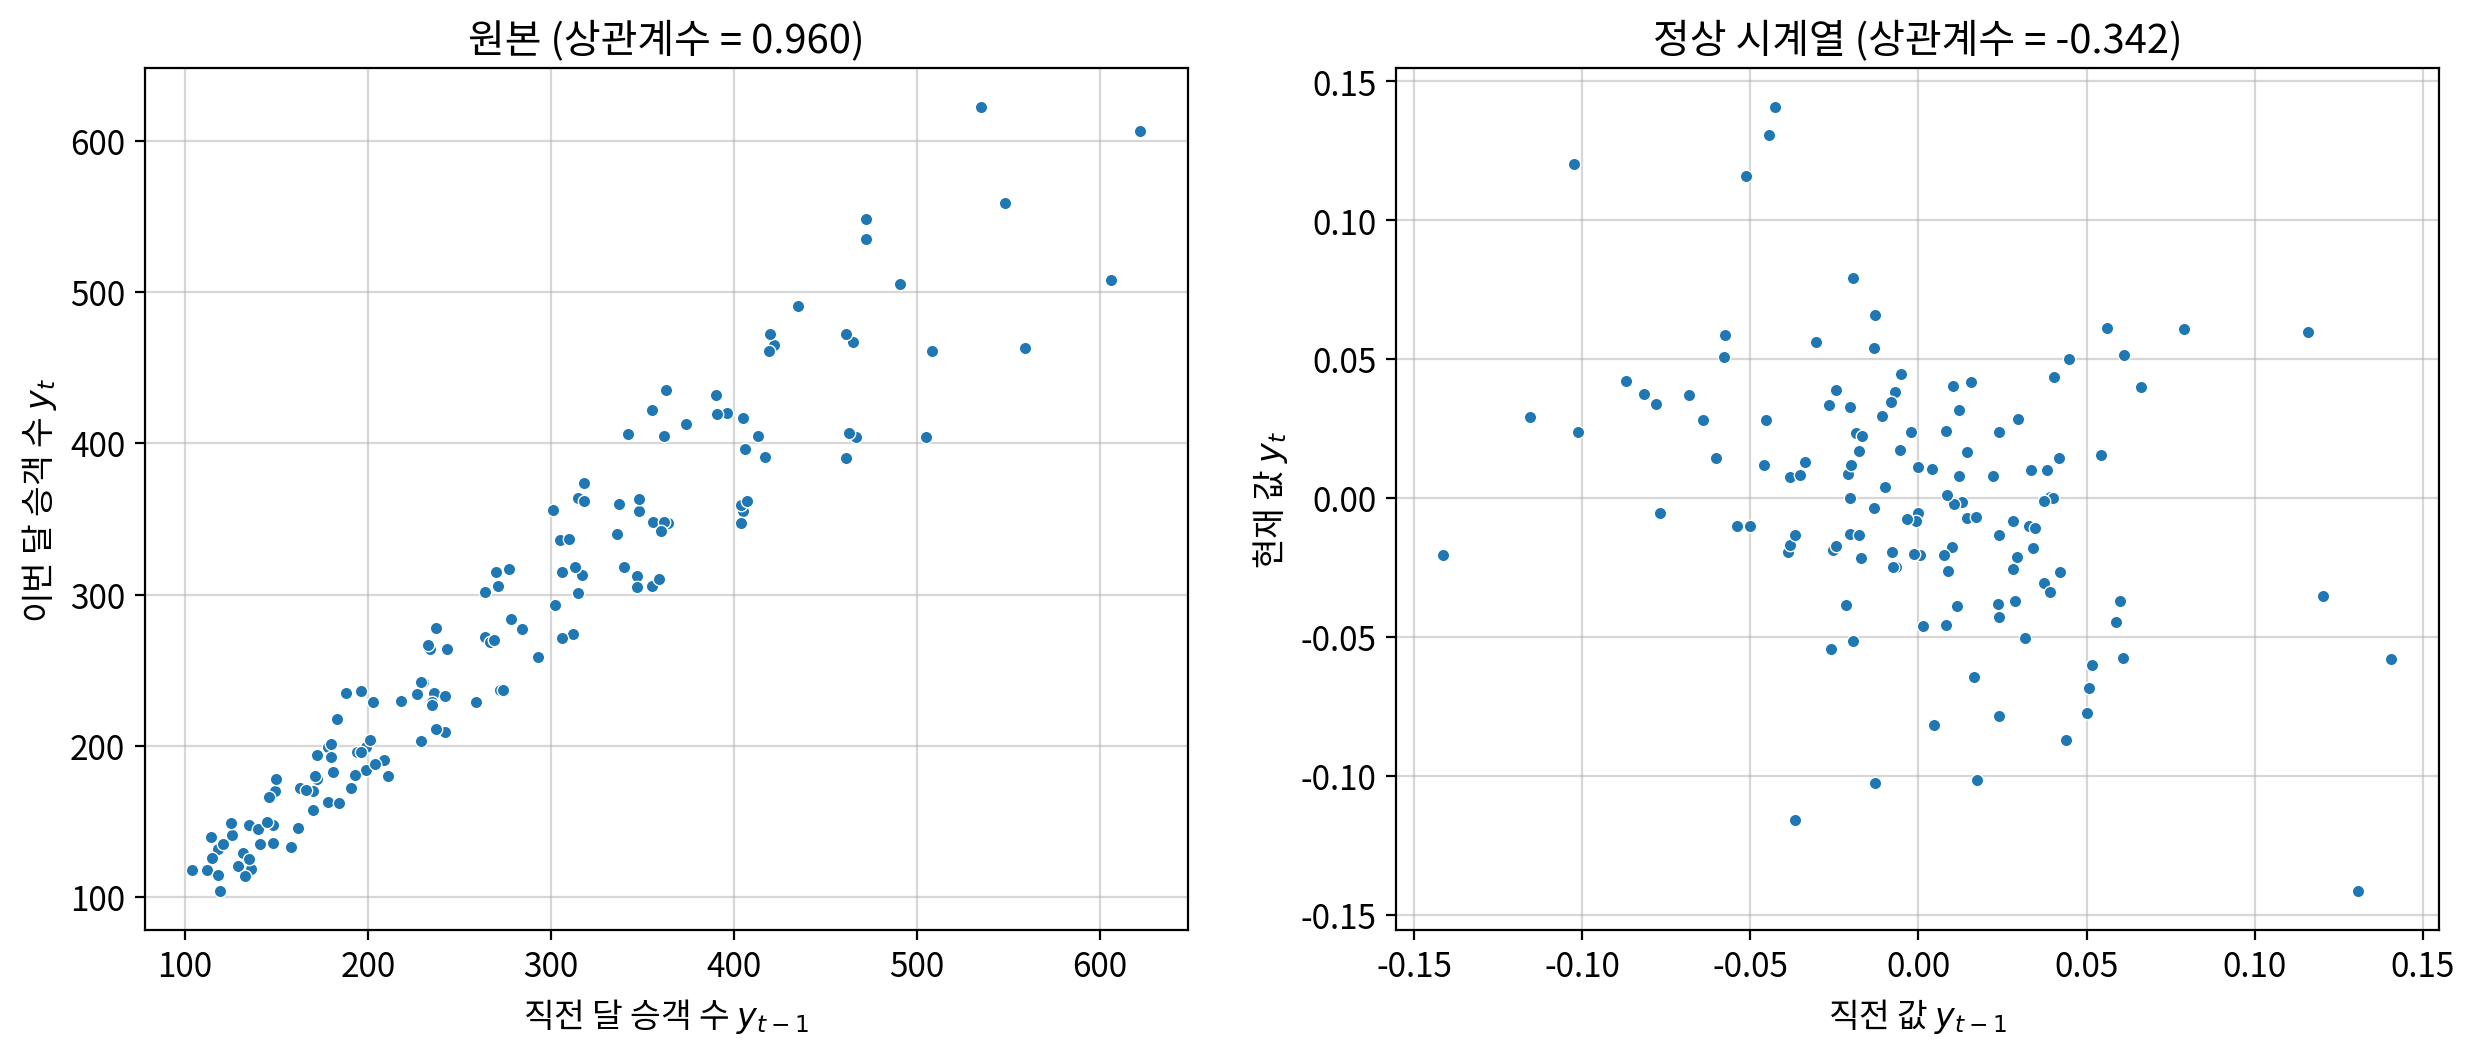

In [6]:
# 그래프 초기화
fig, ax = my_plot.init(rows=1, cols=2, width=740, height=560)

# 원본 : 현재값과 직전값
my_plot.scatterplot(data=or_shift, x='원본 shift', y='원본', size=20, linewidth=0.5, ax=ax[0])
ax[0].set_title(f'원본 (상관계수 = {df['Passengers'].corr(origin_shift):.3f})')
ax[0].set_xlabel('직전 달 승객 수 $y_{t-1}$')
ax[0].set_ylabel('이번 달 승객 수 $y_t$')

# 정상 시계열 : 현재값과 직전값
my_plot.scatterplot(data=st_shift, x='정상 시계열 shift', y='정상 시계열', size=20, linewidth=0.5, ax=ax[1])
ax[1].set_title(f'정상 시계열 (상관계수 = {stationary.corr(stationary_shift):.3f})')
ax[1].set_xlabel('직전 값 $y_{t-1}$')
ax[1].set_ylabel('현재 값 $y_t$')

- 원본의 상관계수 0.960은 아무 의미가 없다. 둘 다 계속 커지고 있기 때문에 자동으로 높게 나오는 것이다.
- 정상 시계열의 -0.342는 진짜 정보다. '지난달에 많이 늘었으면 이번달은 덜 는다'는 되돌림(mean reversion) 패턴을 뜻한다.

## #03.ACF(자기상관함수, Auto Correlation Fuction)
![alt text](image-27.png)

### 1. ACF 시각화
- lag값은 계절 주기의 2배 이상, 최대 관측치길이/4범위로 둔다.
    - 계절주기 2배 : 12개월 x2 = 24
    - 계절주기 3배 : 12개월 x3 = 36
    - 관측치 길이 / 4 : 32.8
- 계절 주기 3배값이 32.8을 초과하므로 36으로 설정하고 33번째부터는 참고하지 않는다.
- 계절주기가 없다면 10*log10(n)와 관측치길이/4 중에서 더 작은값

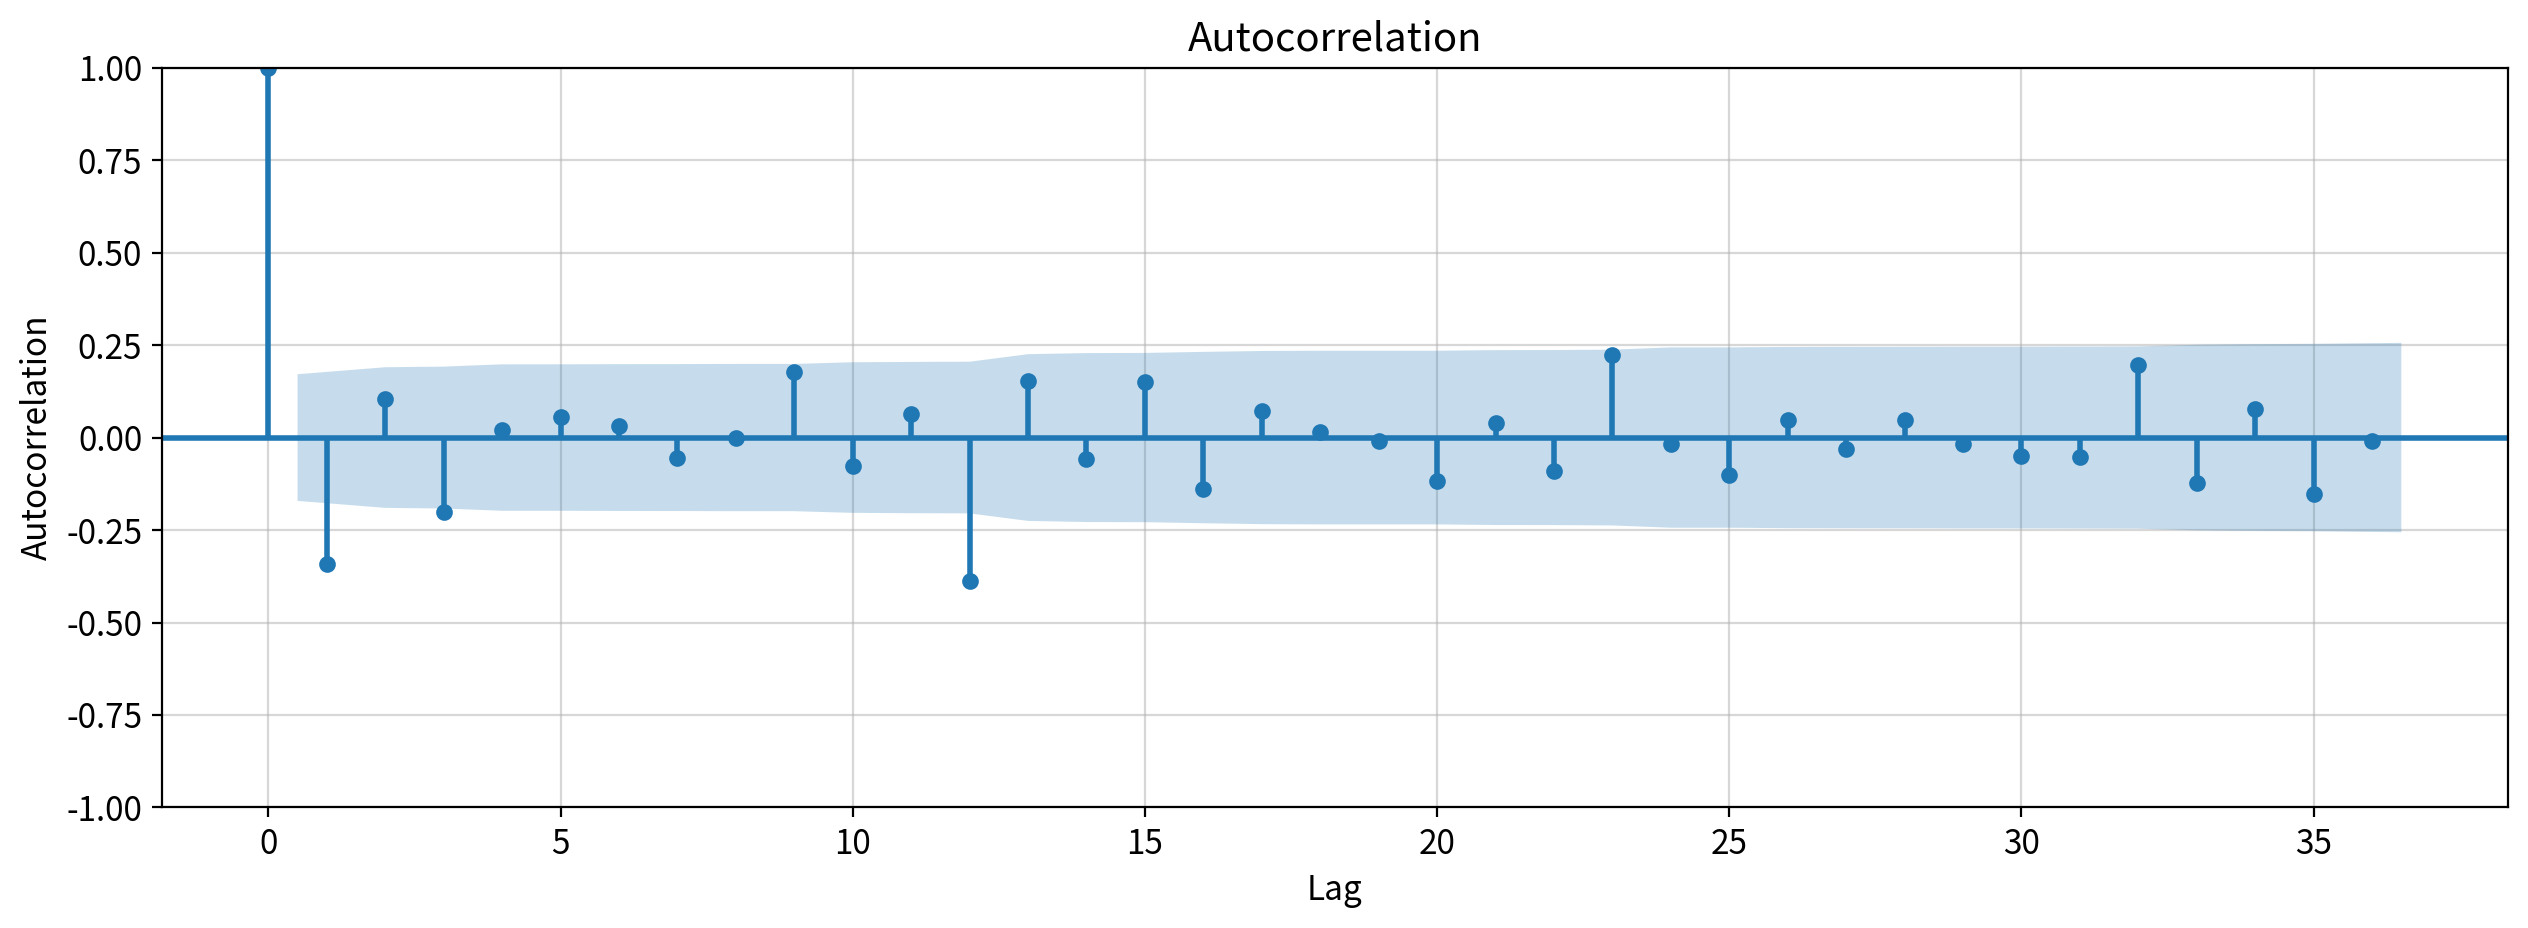

In [7]:
fig, ax = my_plot.init(rows=1, cols=1, width=1280, height=480)

# statsmodels의 plot_acf() 함수를 이용해 정상성 데이터의 자기상관 그래프를 그린다.
plot_acf(stationary, lags=36, ax=ax)   # lag를 계절주기의 3배로 설정함
ax.set_xlabel('Lag')                   # x축은 차시(lag)를 의미함
ax.set_ylabel('Autocorrelation')       # y축은 자기상관계수를 의미함

my_plot.show()

- 파란 음영은 0이라고 봐도 되는 범위 -> 음영 바깥의 막대를 유의한 것으로 판정
    - 막대가 음영 안에 있으면 그 시차의 자기 상관은 통계적으로 0과 다르지 않다.

### 2. 자기상관계수표 만들기
![alt text](image-28.png)

In [8]:
LAGS = 36  # 확인할 최대 시차(계절 주기 12의 3배)
N = len(stationary)  # 관측치 수
THRESHOLD = 2 / np.sqrt(N) # 유의성 기준값
print(f'유의성 기준값: {THRESHOLD:.3f} (관측치 수: {N})')

# lag 0은 자기 자신(항상 1)이므로 판정 대상에서 잘라낸다
acf_values = acf(stationary, nlags=LAGS)[1:]

# DataFrame으로 변환
acf_df = DataFrame({"lag": range(1, LAGS + 1), 'acf': acf_values.round(3)})

# 계수의 절댓값이 기준값을 넘는 데이터인지 판별 (유의성 여부)
acf_df['유의성'] = np.abs(acf_values) > THRESHOLD
acf_df.T

유의성 기준값: 0.175 (관측치 수: 131)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35
lag,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36
acf,-0.341,0.105,-0.202,0.021,0.056,0.031,-0.056,-0.001,0.176,-0.076,0.064,-0.387,0.152,-0.058,0.150,-0.139,0.070,0.016,-0.011,-0.117,0.039,-0.091,0.223,-0.018,-0.100,0.049,-0.030,0.047,-0.018,-0.051,-0.054,0.196,-0.122,0.078,-0.152,-0.010
유의성,True,False,True,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False


### 3. 자기상관계수표 판독
- 유의성이 처음으로 단절되는 지점을 찾는다(없다면 전체 LAG 사용)
- 첫 번째 단절 지점의 직전 지점의 lag값이 우리가 찾는 q값이다.

In [9]:
# 유의성이 단절되는 지점 중 첫번째 지점의 인덱스
fmin = acf_df[acf_df['유의성'] == False].index.min()

# 단절되는 시차가 없으면 전체 LAGS로 설정
if np.isnan(fmin): fmin = LAGS

# q값
print(f'유의성이 단절되는 시차: {acf_df.iloc[fmin-1]['lag']} (q값)')

# 전체 표에서 판정에 사용된 부분만 출력
acf_df[:fmin + 1]

유의성이 단절되는 시차: 1 (q값)


,lag,acf,유의성
0,1,-0.341,True
1,2,0.105,False


## #04. PACF(부분자기상관함수, Partial AutoCorralation)
![alt text](image-29.png)

### 1. PACF 시각화
- 해석방법은 ACF 그래프와 동일하다.

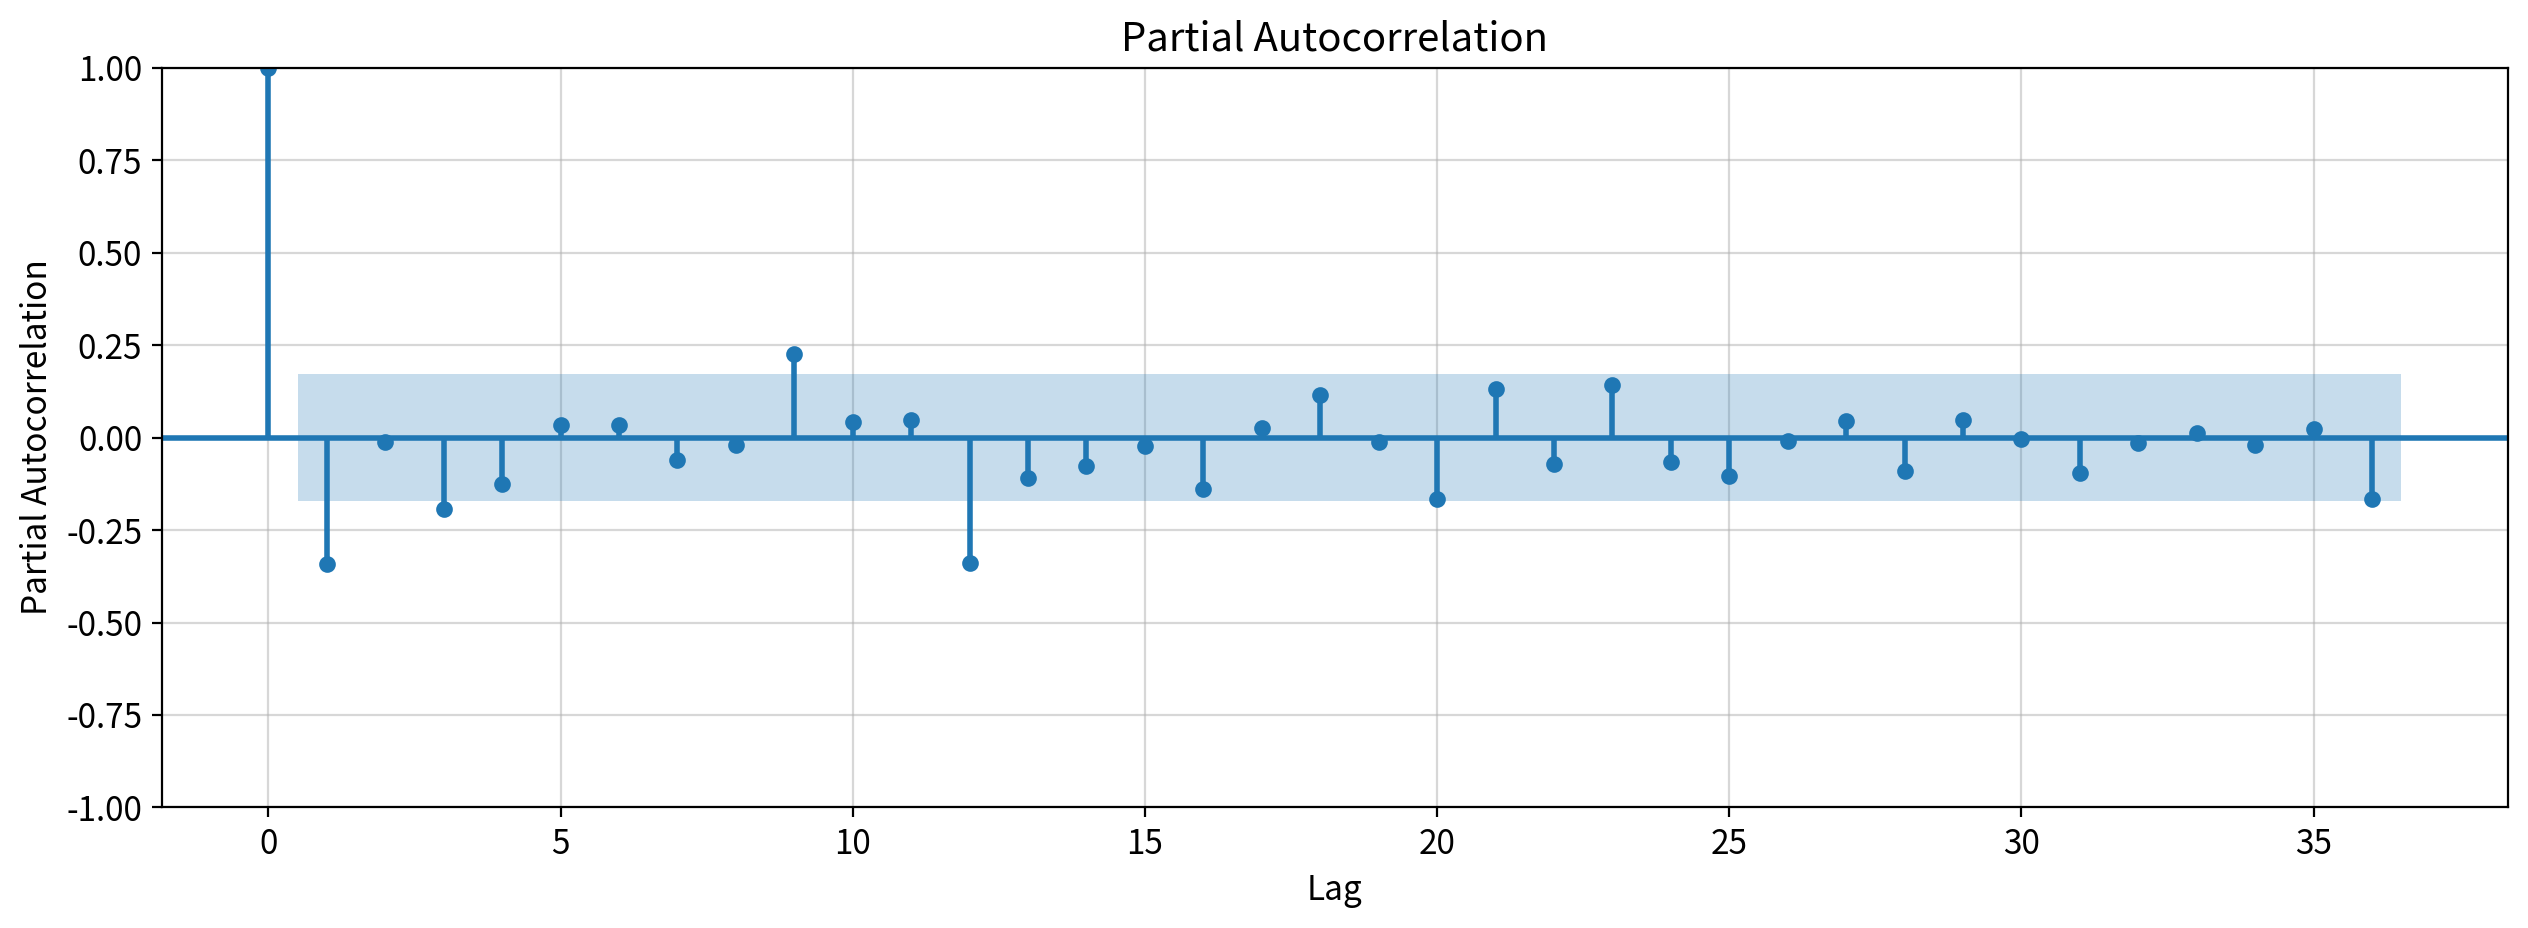

In [10]:
fig, ax = my_plot.init(rows=1, cols=1, width=1280, height=480)

# statsmodels의 plot_pacf() 함수를 이용해 정상성 데이터의 부분자기상관 그래프를 그린다.
plot_pacf(stationary, lags=36, ax=ax)
ax.set_xlabel('Lag')  # x축은 차시(lag)를 의미함
ax.set_ylabel('Partial Autocorrelation') # y축은 부분자기 상관

my_plot.show()

### 2. 부분자기상관계수표
- 사용하는 함수만 acf()에서 pacf()로 변경되고 코드 구성은 동일하다

In [11]:
LAGS = 36                         # 확인할 최대 시차: 계절 주기 12의 3배
N = len(stationary)              # 관측치 수
THRESHOLD = 2 / np.sqrt(N)       # 유의성 기준값

print(f"관측치 {N}개 | 유의성 기준값 {THRESHOLD:.4f}")

# lag 0은 자기 자신과의 상관이므로 판정 대상에서 제외
pacf_values = pacf(
    stationary,
    nlags=LAGS
)[1:]

# DataFrame으로 변환
pacf_df = DataFrame({
    "lag": range(1, LAGS + 1),
    "pacf": pacf_values.round(3)
})

# PACF의 절댓값이 기준값을 넘으면 유의한 시차로 판단
pacf_df["유의성"] = np.abs(pacf_values) > THRESHOLD

# 결과 출력
pacf_df.T

관측치 131개 | 유의성 기준값 0.1747


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35
lag,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36
pacf,-0.344,-0.013,-0.198,-0.130,0.034,0.036,-0.064,-0.022,0.244,0.048,0.051,-0.378,-0.127,-0.091,-0.022,-0.166,0.030,0.144,-0.005,-0.211,0.162,-0.088,0.190,-0.106,-0.132,-0.017,0.074,-0.138,0.070,-0.017,-0.120,-0.027,0.021,-0.037,0.047,-0.271
유의성,True,False,True,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True


### 3. 부분자기상관계수표 판독
- acf() 판독과 동일한 방법을 사용한다

In [12]:
# 유의성이 단절되는 지점 중 첫 번째 지점의 인덱스
fmin = pacf_df[pacf_df['유의성'] == False].index.min()

# 단절되는 시차가 없으면 전체 LAGS로 설정
if np.isnan(fmin) : fmin = LAGS

# p값
print(f'유의성이 단절되는 시차: {pacf_df.iloc[fmin-1]['lag']} (p값)')

# 전체 표에서 판정에 사용된 부분만 출력
pacf_df[:fmin + 1]


유의성이 단절되는 시차: 1 (p값)


,lag,pacf,유의성
0,1,-0.344,True
1,2,-0.013,False


![alt text](image-30.png)

## #05. 계절 차수(P, Q)도출
![alt text](image-31.png)

### 1. 판정 대상 계절 시차 추리기
- 계절 시차는 주기의 배수(12, 24, 36)뿐이다. 그 사이의 시차는 P, Q 판정에 쓰지 않는다.
    - 단 #03에서 정한 상한 관측치 수 /4 = 32.8을 넘는 36은 제외한다.
    - 뒤쪽 시차일수록 계산에 쓰이는 쌍이 줄어 값을 믿을 수 없기 대문이다.

In [13]:
PERIOD = 12                    # 계절 주기 (1~3단원에서 확정)
LIMIT = N // 4                 # 판정 상한

# 계절 주기의 배수 중 상한 이내인 시차만 판정 대상으로 삼는다
season_lags = []

# 계절 주기 배수 시차 단위로 판정 상한까지 반복하여 판정 대상 시차를 구한다
for k in range(PERIOD, LAGS + 1, PERIOD):
    if k <= LIMIT:
        season_lags.append(k)

print(f"판정 상한: lag {LIMIT} | 판정 대상 계절 시차: {season_lags}")

판정 상한: lag 32 | 판정 대상 계절 시차: [12, 24]


### 2. 계절 시차의 계수만 모으기
- 새로 계산할 것은 없다. 앞에서 만든 acf_df, pacf_df에서 계절 시차 행만 뽑는다.
- 유의성 기준값도 비계절 판정에 쓴 0.175를 그대로 쓴다.
    - 판정 기준은 시차가 아니라 관측치 수로 정해지기 때문이다.

In [14]:
# lag를 인덱스로 바꾸면 원하는 시차의 행을 바로 꺼낼 수 있다
acf_idx = acf_df.set_index("lag")
pacf_idx = pacf_df.set_index("lag")

season_df = DataFrame({
    "lag": season_lags,
    "주기 배수": [f"{k // PERIOD}배" for k in season_lags],
    "acf": acf_idx.loc[season_lags, "acf"].values,
    "acf 유의성": acf_idx.loc[season_lags, "유의성"].values,
    "pacf": pacf_idx.loc[season_lags, "pacf"].values,
    "pacf 유의성": pacf_idx.loc[season_lags, "유의성"].values,
})

season_df

,lag,주기 배수,acf,acf 유의성,pacf,pacf 유의성
0,12,1배,-0.387,True,-0.378,True
1,24,2배,-0.018,False,-0.106,False


### 3. 계절 차수 판정
- 판정 규칙은 비계절과 똑같다. 단위만 1시차에서 1주기로 바뀐다.
- 유의성이 처음으로 단절되는 지점을 찾고, 그 직전까지의 배수 개수가 곧 차수다

In [15]:
# 유의성이 단절되는 지점 중 첫 번째 지점의 인덱스
acf_break = season_df[season_df["acf 유의성"] == False].index.min()
pacf_break = season_df[season_df["pacf 유의성"] == False].index.min()

# 단절되는 지점이 없으면 마지막 배수까지 모두 유의한 것이다
if np.isnan(acf_break):
    acf_break = len(season_df)

if np.isnan(pacf_break):
    pacf_break = len(season_df)

# 인덱스는 0부터 시작하므로 단절 지점의 인덱스가
# 곧 직전까지 연속으로 유의한 배수의 개수가 된다
Q = int(acf_break)     # 계절 ACF → 계절 MA 차수
P = int(pacf_break)    # 계절 PACF → 계절 AR 차수

print(
    f"계절 MA 차수 후보 (Q): {Q} "
    f"← 계절 ACF가 1배수부터 연속으로 유의한 구간 {Q}개"
)

print(
    f"계절 AR 차수 후보 (P): {P} "
    f"← 계절 PACF가 1배수부터 연속으로 유의한 구간 {P}개"
)

계절 MA 차수 후보 (Q): 1 ← 계절 ACF가 1배수부터 연속으로 유의한 구간 1개
계절 AR 차수 후보 (P): 1 ← 계절 PACF가 1배수부터 연속으로 유의한 구간 1개


## #05. 모듈화 기능 확인
### 1. ACF, PACF 일괄 판정 + 시각화

관측치 131개 | 유의성 기준값 0.175 | 최대 시차 32 (상한 N/4=32)
AR 차수 후보 (p): 1   ← PACF가 lag 1 이후 절단
MA 차수 후보 (q): 1   ← ACF가 lag 1 이후 절단
계절 AR 차수 후보 (P): 1   ← 계절 PACF가 lag 12 이후 절단 (판정 시차 [12, 24])
계절 MA 차수 후보 (Q): 1   ← 계절 ACF가 lag 12 이후 절단 (판정 시차 [12, 24])
→ SARIMA(1, d, 1)(1, D, 1)[12] — d·D 는 차분 단계의 결과를 넣는다


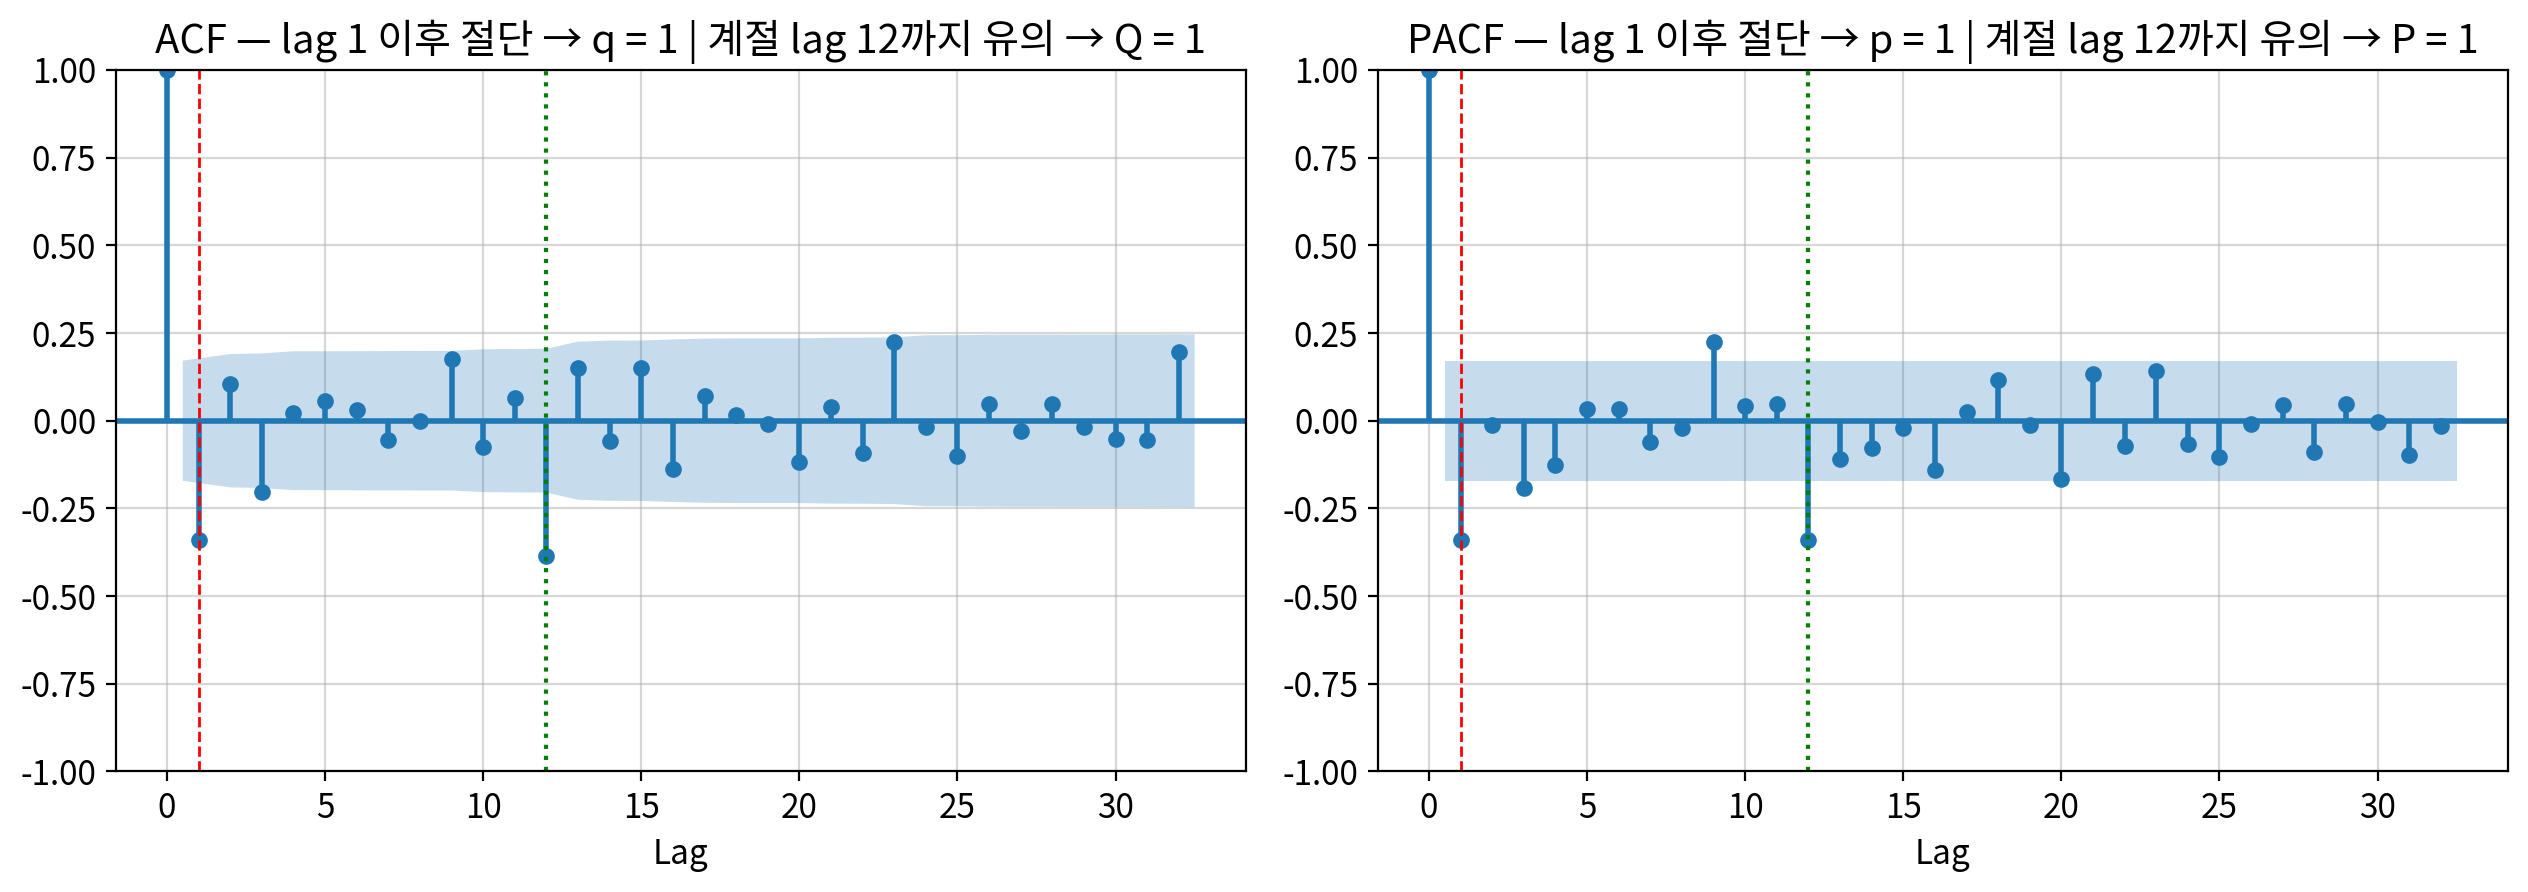

,acf,acf 유의성,pacf,pacf 유의성,기준값,p,q,P,Q
lag,,,,,,,,,
1,-0.341,True,-0.344,True,0.175,◀,◀,,
2,0.105,False,-0.013,False,0.175,,,,
3,-0.202,True,-0.198,True,0.175,,,,
4,0.021,False,-0.130,False,0.175,,,,
5,0.056,False,0.034,False,0.175,,,,
6,0.031,False,0.036,False,0.175,,,,
7,-0.056,False,-0.064,False,0.175,,,,
8,-0.001,False,-0.022,False,0.175,,,,
9,0.176,True,0.244,True,0.175,,,,


In [16]:
my_ts.auto_correlation(stationary, period=12, rows=1, cols=2, width=640, height=480)